# Simulated IRFs from RBC Model

This code creates a very simple RBC model with random technology shocks. Data from this model is simulated, the true IRFs are created, and then the IRFs are estimated using VAR and SLP estimation.

The model has period utility $u_t=\log(C_t)$, production function $Y_t = e^{z_t}K^{\alpha}_t$, technology evolution $z_t = \rho z_{t-1}+\varepsilon_t$ with $\varepsilon_t \sim \mathcal N(0,\sigma^2)$, and resource constraint $C_t+K_{t+1}=Y_t$. The econometrician observes $K_t, Y_t, Z_t$ with noise, where $Z_t=e^{z_t}$. The advantage of this simple model (with full depreciation and inelastic labour) is that the policy funciton of the household has a closed-form solution.

In [2]:
# import packages
import statsmodels as sm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR

In [3]:
# set parameters
beta = 0.99 # quarterly discount factor
alpha = 0.33 # capital share in production function
rho = 0.9 # persistence of technology shock
sigma_z = 0.05 # standard deviation of technology shock
sigma_obs = 0.025 # standard deviation of measurement error in observed data
q = 20 # number of quarters for IRF
T = 200 # number of quarters for simulated data

np.random.seed(1371) # set seed for reproducibility

### Generating observed data

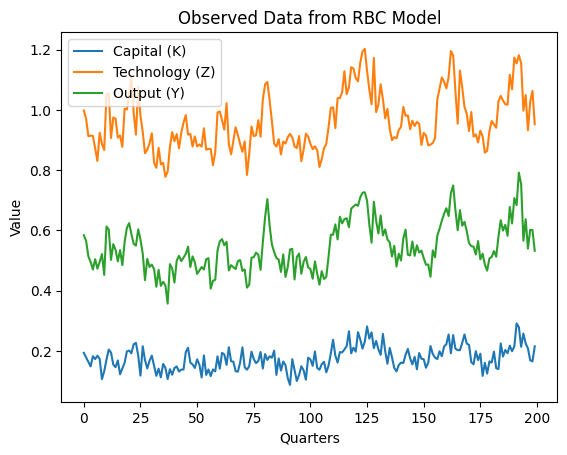

In [4]:
# create simulated time series data for simple RBC model
def gen_macro_ts(beta, alpha, rho, sigma_z, sigma_obs, T):
    ss_K = (1/(beta*alpha))**(1/(alpha-1))
    ss_C = ss_K**alpha - ss_K

    K = np.zeros(T)
    C = K.copy()
    z = K.copy()
    Y = K.copy()

    K[0] = ss_K
    C[0] = ss_C
    Y[0] = K[0]**alpha

    for t in range(1, T):
        z[t] = rho * z[t-1] + sigma_z * np.random.normal()
        K[t] = alpha * beta * np.exp(z[t-1]) * K[t-1]**alpha # closed-form solution for capital accumulation
        C[t] = (1-alpha*beta) * np.exp(z[t]) * K[t]**alpha # closed-form solution for consumption
        
    Z = np.exp(z) + np.random.normal(0, sigma_obs, size=T) # add measurement error to observed Z
    Y = Z*K**alpha + np.random.normal(0, sigma_obs, size=T) # add measurement error to observed Y
    K = K + np.random.normal(0, sigma_obs, size=T) # add measurement error to observed K

    return pd.DataFrame({"K": K, "Z": Z, "Y": Y})

observed_data = gen_macro_ts(beta, alpha, rho, sigma_z, sigma_obs, T)

plt.plot(observed_data)
plt.title("Observed Data from RBC Model")
plt.xlabel("Quarters")
plt.ylabel("Value")
plt.legend(["Capital (K)", "Technology (Z)", "Output (Y)"])
plt.show()

### Generating the true IRFs

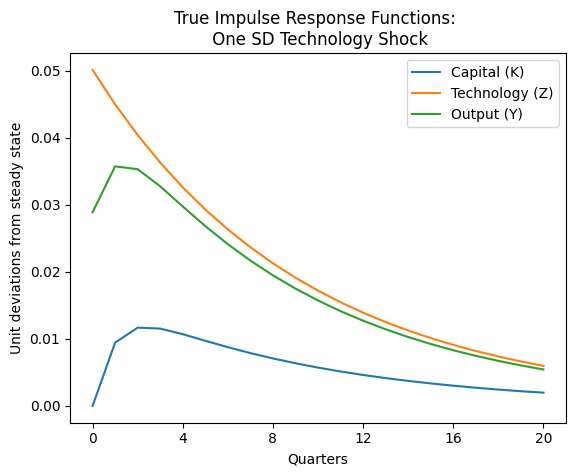

In [5]:
# simulated IRF for a one SD technology shock
# this is the true IRF that the econometrician is trying to estimate from observed data
def gen_irf(beta, alpha, rho, sigma, q):
    ss_K = (1/(beta*alpha))**(1/(alpha-1))
    ss_C = ss_K**alpha - ss_K

    K = np.zeros(q+1)
    C = K.copy()
    z = K.copy()
    Y = K.copy()

    z[0] = np.log(np.sqrt((np.exp(sigma**2)-1)*np.exp(sigma**2))+1) # one SD shock to observed Z
    K[0] = ss_K
    C[0] = ss_C

    for t in range(1, q+1):
        z[t] = rho * z[t-1]
        K[t] = alpha * beta * np.exp(z[t-1]) * K[t-1]**alpha
        C[t] = (1-alpha*beta) * np.exp(z[t]) * K[t]**alpha

    Z = np.exp(z) - 1
    Y = np.exp(z)*K**alpha - ss_K**alpha
    K = K - ss_K

    return pd.DataFrame({"K": K, "Z": Z, "Y": Y,})

true_irf = gen_irf(beta, alpha, rho, sigma_z, q)

plt.plot(true_irf)
plt.title("True Impulse Response Functions: \n One SD Technology Shock")
plt.xlabel("Quarters")
plt.ylabel("Unit deviations from steady state")
plt.xticks(range(0, q+1, 4))
plt.legend(["Capital (K)", "Technology (Z)" , "Output (Y)"])
plt.show()

### Estimating the IRFs using VAR

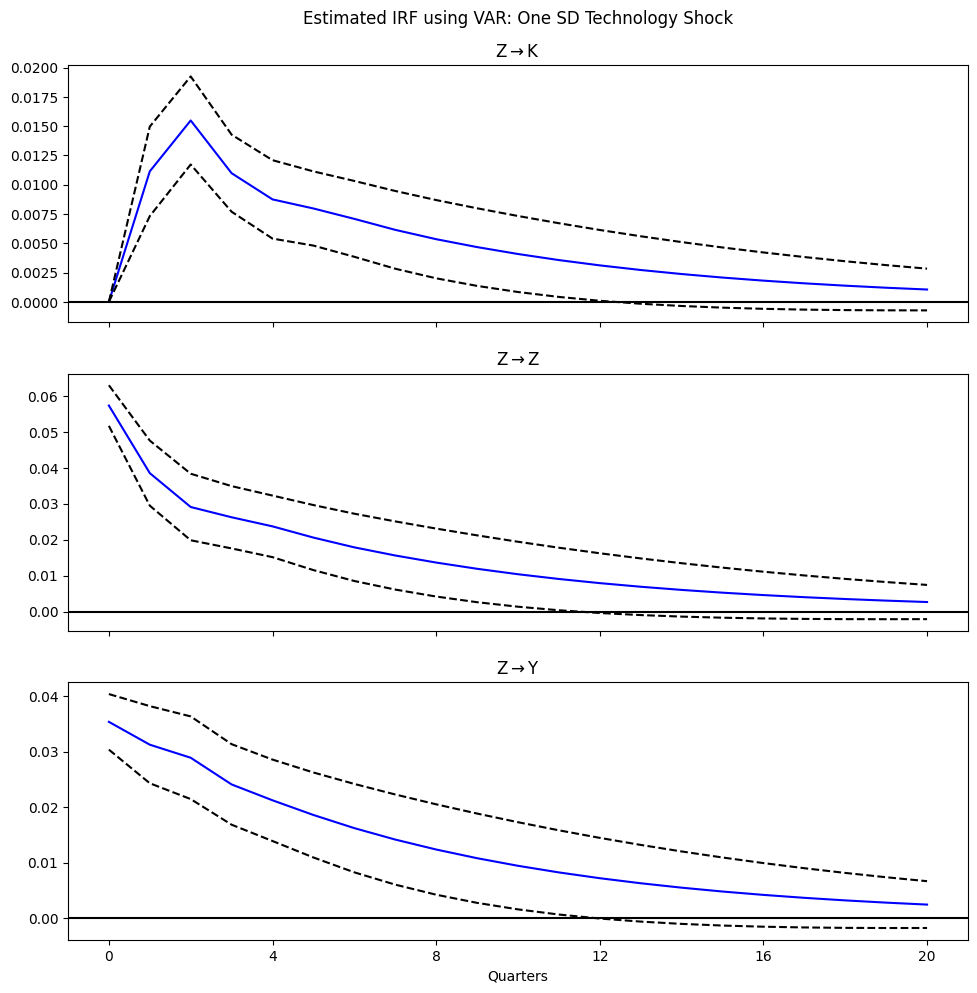

In [6]:
# estimating IRF using VAR model on observed data
def estimate_irf(data, q):
    model = VAR(data)
    results = model.fit(ic="aic")
    irf = results.irf(q)
    return irf
VAR_irf = estimate_irf(observed_data, q)
VAR_irf.plot(orth=True, impulse = "Z")
plt.suptitle("Estimated IRF using VAR: One SD Technology Shock")
plt.xlabel("Quarters")
plt.xticks(range(0, q+1, 4))
plt.show()

### Estimating the IRFs using local projections

In [7]:
# estimating IRF using LPs on observed data


### Estimating the IRFs using smooth local projections

In [8]:
# estimating IRF using SLPs on observed data
